In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
rfm = pd.read_csv('../data/rfm_data.csv')

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [2]:
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

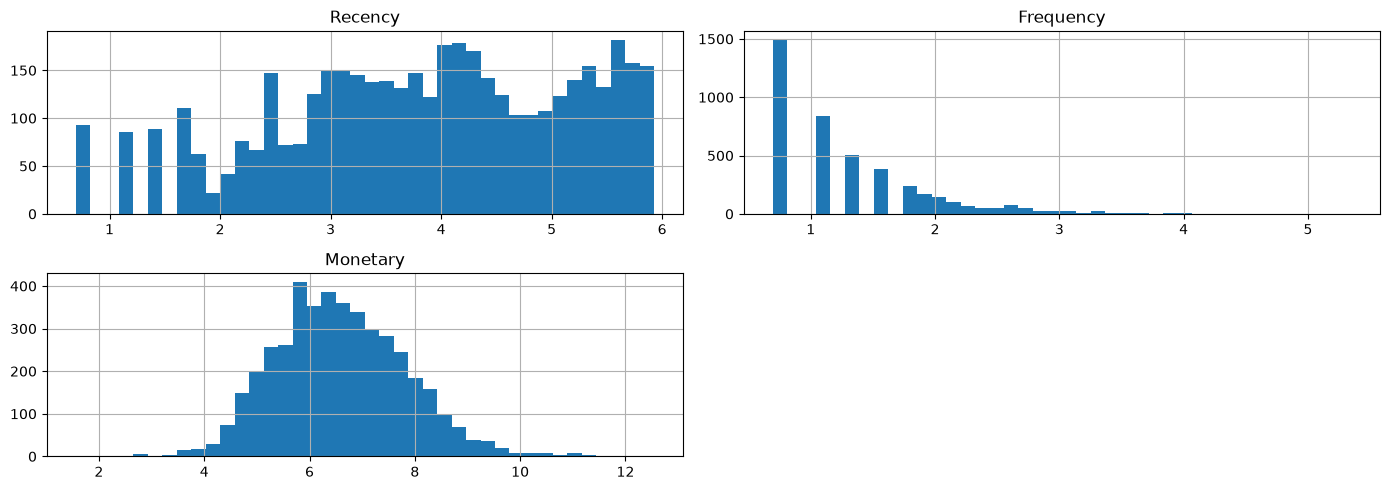

In [3]:
features = ["Recency", "Frequency", "Monetary"]

rfm_log = rfm.copy()

rfm_log[features] = np.log1p(rfm_log[features])

rfm_log[features].hist(bins=40, figsize=(14, 5))

plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(rfm_log[features])

print("Dimensions de X :", X.shape)
print("Moyennes :", X.mean(axis=0).round(2))
print("Ecarts types :", X.std(axis=0).round(2))
X

Dimensions de X : (4338, 3)
Moyennes : [-0. -0. -0.]
Ecarts types : [1. 1. 1.]


array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       ...,
       [-1.21893976, -0.36158278, -1.11333158],
       [-1.65755161,  2.17800394,  0.82281217],
       [-0.03473174,  0.05960547,  0.73752572]], shape=(4338, 3))

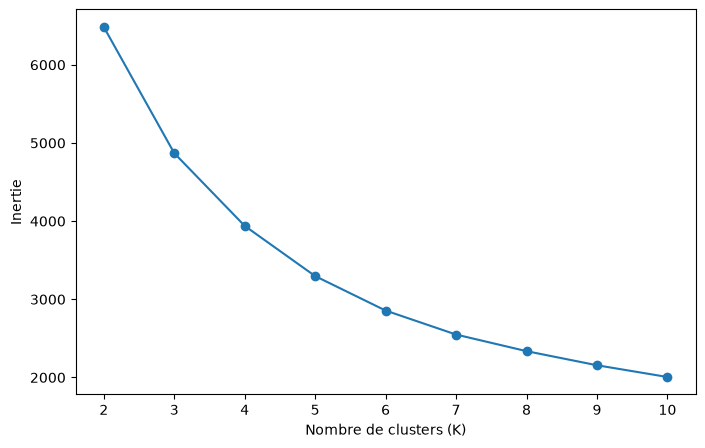

In [5]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.xticks(list(k_values))
plt.show()

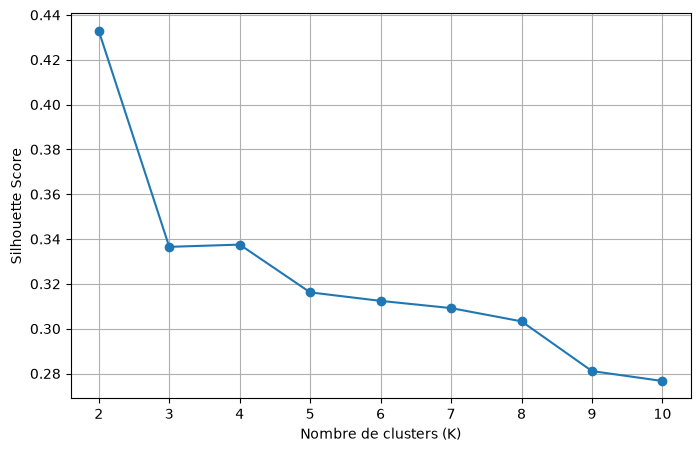

In [6]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [7]:
import pandas as pd

results = pd.DataFrame({
    "K": list(range(2, 11)),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

display(results.round(3))

,K,Inertia,Silhouette Score
0,2,6483.589,0.433
1,3,4869.489,0.337
2,4,3939.049,0.338
3,5,3296.709,0.316
4,6,2855.764,0.312
5,7,2548.820,0.309
6,8,2336.341,0.303
7,9,2156.006,0.281
8,10,2005.746,0.277


In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X)

print("Nombre de clients par cluster :")
print(rfm["Cluster"].value_counts().sort_index())

print("\nmoyen de chaque cluster :")
print(
    rfm.groupby("Cluster")[
        ["Recency", "Frequency", "Monetary"]
    ].mean().round(2)
)

Nombre de clients par cluster :
Cluster
0     769
1    1872
2    1697
Name: count, dtype: int64

moyen de chaque cluster :
         Recency  Frequency  Monetary
Cluster                              
0          17.06      13.35   7898.46
1         167.36       1.35    361.00
2          44.20       3.38   1259.58


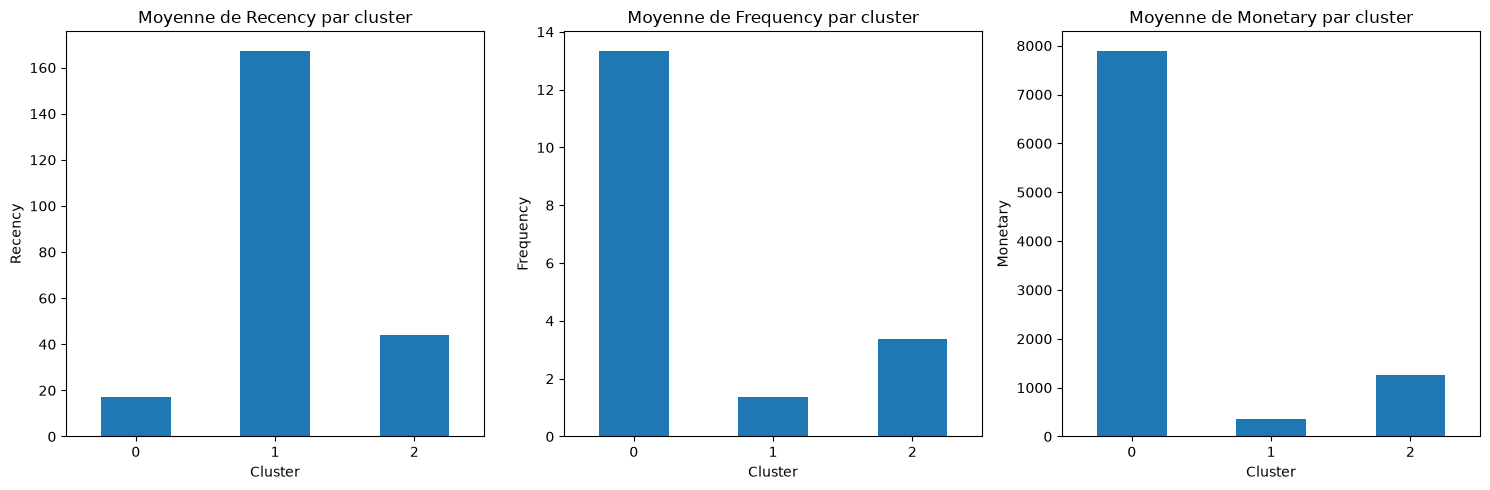

In [9]:
import matplotlib.pyplot as plt

features = ["Recency", "Frequency", "Monetary"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, features):
    means = rfm.groupby("Cluster")[feature].mean()
    means.plot(kind="bar", ax=ax)
    ax.set_title(f"Moyenne de {feature} par cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(feature)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

X_pca.shape

pca.explained_variance_ratio_

array([0.75078634, 0.18786648])

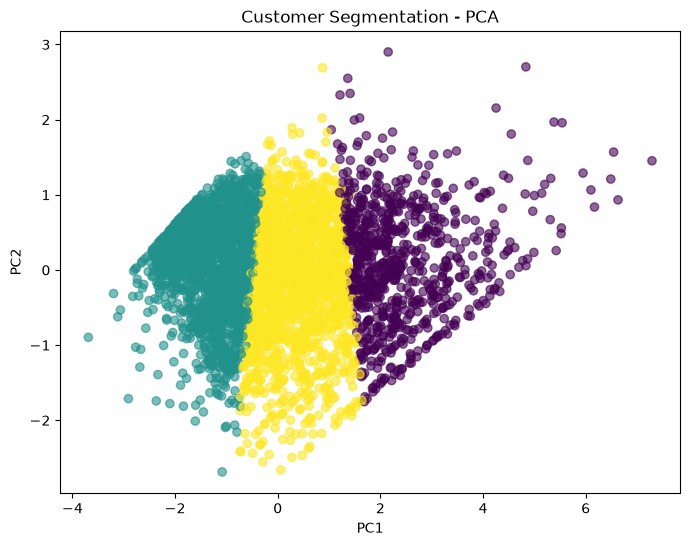

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation - PCA")
plt.show()